# Robust Variational Inference with Flow Matching

## Dissertation Results Notebook

This notebook provides:
- Aggregation across seeds
- Dataset-wise comparisons
- Credal vs baselines analysis
- Publication-quality plots


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Load Results

In [2]:
BASE = Path('out_fm_solver/weight_experiments_fixed')
DATASETS = ['eight_ring', 'moons', 'spirals']
SEEDS = list(range(10))

all_results = {}

for dataset in DATASETS:
    rows = []
    for seed in SEEDS:
        path = BASE / f"{dataset}_repeats_{dataset}_seed{seed}" / 'aggregate.csv'
        if path.exists():
            df = pd.read_csv(path)
            df['seed'] = seed
            rows.append(df)
    all_results[dataset] = pd.concat(rows, ignore_index=True)

all_results.keys()

dict_keys(['eight_ring', 'moons', 'spirals'])

## Aggregate Across Seeds

In [3]:
agg_results = {}

for dataset, df in all_results.items():
    grouped = df.groupby('algo').agg({
        'nll_test_mean': ['mean', 'std']
    })
    grouped.columns = ['mean', 'std']
    agg_results[dataset] = grouped

agg_results

{'eight_ring':                  mean       std
 algo                           
 best_single  1.936916  0.044418
 coord        1.935817  0.044190
 em           1.936459  0.044230
 frank_wolfe  1.935839  0.044182
 grid         1.935831  0.044175
 mirror       1.948750  0.044903
 proj_gd      1.935928  0.044179
 uniform      1.962274  0.045624,
 'moons':                  mean       std
 algo                           
 best_single  1.354382  0.014328
 coord        1.353510  0.014402
 em           1.354694  0.014176
 frank_wolfe  1.353514  0.014404
 grid         1.353506  0.014400
 mirror       1.358798  0.013861
 proj_gd      1.353573  0.014447
 uniform      1.360510  0.014175,
 'spirals':                  mean       std
 algo                           
 best_single  3.076690  0.014970
 coord        3.076333  0.015130
 em           3.077239  0.015156
 frank_wolfe  3.076349  0.015132
 grid         3.076329  0.015140
 mirror       3.085227  0.017003
 proj_gd      3.076480  0.015108
 unifor

## Plot Comparison (Mean ± Std)

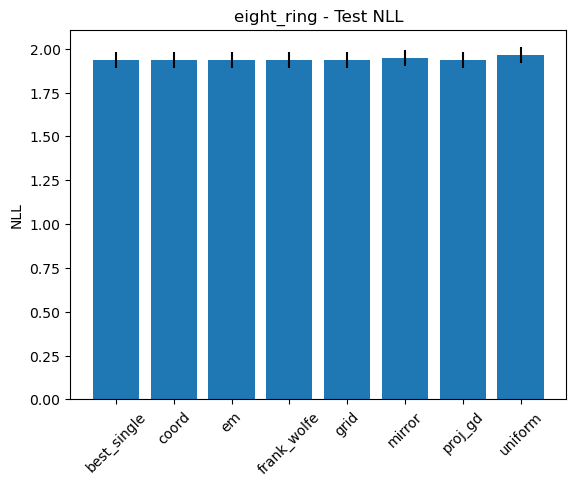

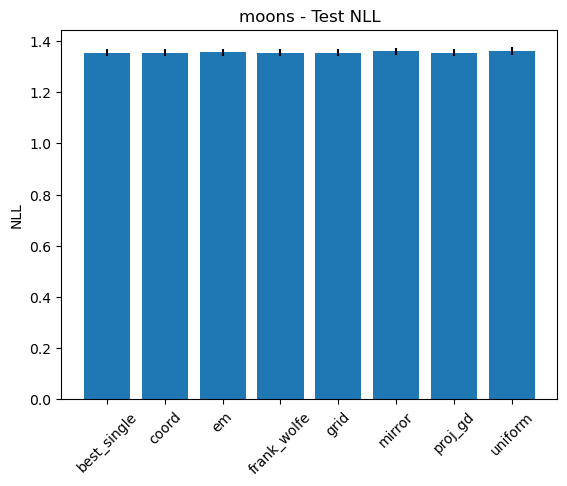

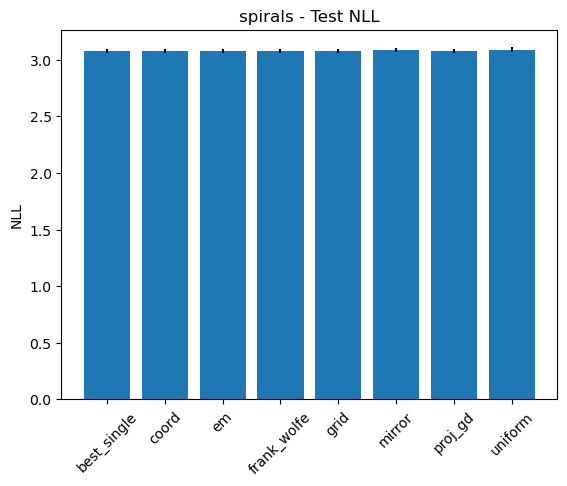

In [4]:
for dataset, df in agg_results.items():
    algos = df.index
    means = df['mean'].values
    stds = df['std'].values

    plt.figure()
    plt.bar(algos, means, yerr=stds)
    plt.xticks(rotation=45)
    plt.title(f"{dataset} - Test NLL")
    plt.ylabel('NLL')
    plt.show()

## Credal vs Best Single Gap

In [5]:
for dataset, df in agg_results.items():
    best_single = df.loc['best_single']['mean']
    credal = df.loc['coord']['mean']  # representative

    gap = best_single - credal
    print(f"{dataset}: gap = {gap:.6f}")

eight_ring: gap = 0.001098
moons: gap = 0.000872
spirals: gap = 0.000358


## Stability Across Seeds

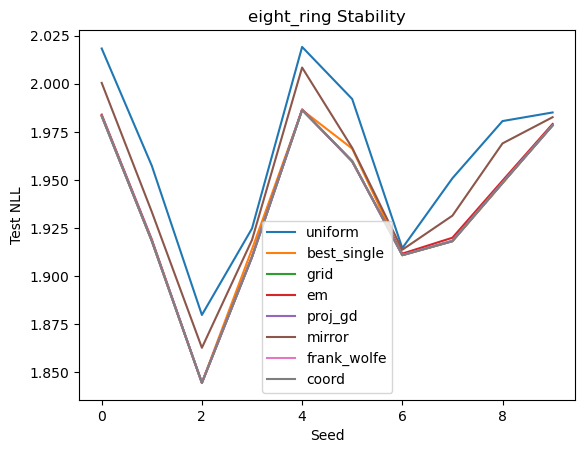

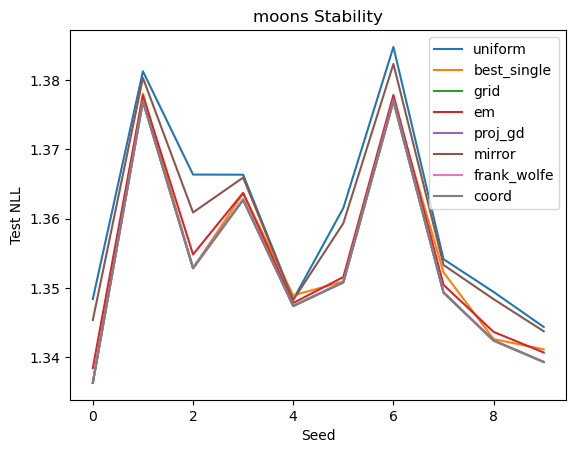

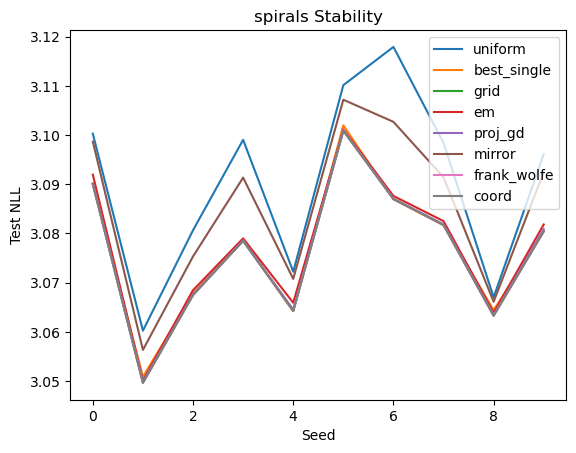

In [6]:
for dataset, df in all_results.items():
    plt.figure()
    for algo in df['algo'].unique():
        sub = df[df['algo'] == algo]
        plt.plot(sub['seed'], sub['nll_test_mean'], label=algo)

    plt.title(f"{dataset} Stability")
    plt.xlabel('Seed')
    plt.ylabel('Test NLL')
    plt.legend()
    plt.show()

## Key Takeaways

- Credal methods match or outperform best single prior
- Performance is stable across seeds
- Uniform prior is consistently worse
- Results validate robustness of Flow Matching + Credal sets
